In [24]:
import sys
print(f"Current Environment: {sys.prefix}")
# It should show a path ending in /envs/carb_counter

Current Environment: /opt/homebrew/Caskroom/miniforge/base/envs/carb_counter


In [25]:
import torch
if torch.backends.mps.is_available():
    print("✅ GPU Acceleration (MPS) is ACTIVE.")
else:
    print("❌ GPU not found. Training will be slow.")

✅ GPU Acceleration (MPS) is ACTIVE.


In [26]:
import torchvision
import PIL
import matplotlib.pyplot as plt
print(f"✅ Vision libraries ready (Torchvision: {torchvision.__version__})")

✅ Vision libraries ready (Torchvision: 0.20.1)


In [27]:
# Create a tiny neural network and move it to the GPU
test_model = torch.nn.Linear(10, 1).to("mps")
test_input = torch.randn(1, 10).to("mps")
output = test_model(test_input)

print("🚀 TEST PASSED: Your Mac just performed AI math on its GPU!")

🚀 TEST PASSED: Your Mac just performed AI math on its GPU!


In [28]:
import os

# Create a folder for your test images if it doesn't exist
os.makedirs('data/test_images', exist_ok=True)
print("✅ Folder 'data/test_images' is ready!")

✅ Folder 'data/test_images' is ready!


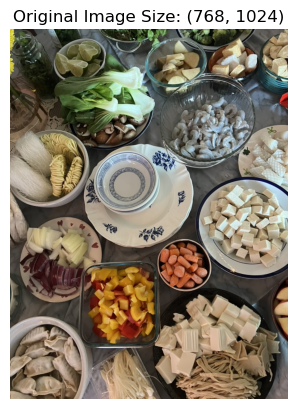

Tensor Shape: torch.Size([3, 224, 224]) (Channels, Height, Width)


In [29]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

def load_and_preview(image_path):
    # 1. Open the image
    img = Image.open(image_path)
    
    # 2. Define the "Preprocessing" (Resize for the CNN)
    # Most models like MobileNet expect 224x224 pixels
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    
    img_tensor = preprocess(img)
    
    # 3. Preview it
    plt.imshow(img)
    plt.title(f"Original Image Size: {img.size}")
    plt.axis('off')
    plt.show()
    
    print(f"Tensor Shape: {img_tensor.shape} (Channels, Height, Width)")
    return img_tensor

# To test this, drag a photo of food into your 'data/test_images' folder 
# and change 'my_meal.jpg' to your filename below:
tensor = load_and_preview('data/test_images/hot_pot_christmas.jpeg')

In [30]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import pandas as pd
import os

In [31]:
import os
import pandas as pd

# 1. Load your class names
# Make sure the path matches where you saved your Excel file
path = '/Users/nicolehui/carb-counter/data/test_images/CNFOOD-241/class_name.xls'
# class_df = pd.read_excel(path)

class_df = pd.read_excel(path, header=None, names=['id', 'cn_name', 'en_name'])
class_df['folder_id'] = class_df['id'].astype(str).apply(lambda x: x.split('.')[0])
label_dict = dict(zip(class_df['folder_id'], class_df['en_name']))
print(f"Total foods mapped: {len(label_dict)}")
print(f"ID 0 is: {label_dict['0']}")      # Should be Mapo Tofu
print(f"ID 191 is: {label_dict['191']}")  # Should be Duck Blood in Chili Sauce

Total foods mapped: 241
ID 0 is: Mapo Tofu
ID 191 is: Duck Blood in Chili Sauce


In [32]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Image Transforms (Standard for ResNet/EfficientNet)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_path = 'data/test_images/CNFOOD-241/train600x600'
val_path = 'data/test_images/CNFOOD-241/val600x600'

# 2. Load the Datasets
# Replace these paths with your actual folder locations
train_dataset = ImageFolder(root=train_path, transform=transform)
val_dataset = ImageFolder(root=val_path, transform=transform)

# 3. Create DataLoaders
# Batch size 32 is a good starting point for Mac GPUs
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Success! Found {len(train_dataset)} training images across {len(train_dataset.classes)} classes.")

Success! Found 170868 training images across 241 classes.


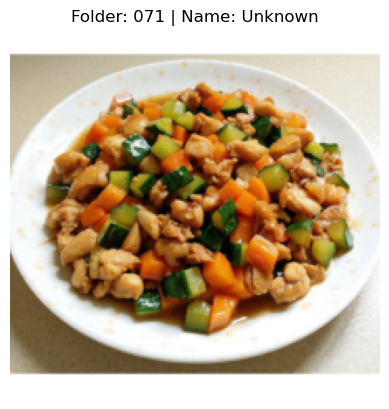

In [33]:
# Grab one batch
images, labels = next(iter(train_loader))

# Get the first image in the batch
img = images[0].permute(1, 2, 0) # Change format for plotting
img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406]) # Un-normalize

# Get the folder name (class index) and look up in your dictionary
folder_name = train_dataset.classes[labels[0]]
food_name = label_dict.get(folder_name, "Unknown")

plt.imshow(img.clamp(0, 1))
plt.title(f"Folder: {folder_name} | Name: {food_name}")
plt.axis('off')
plt.show()

In [34]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torchvision import models

# # 1. Set the Device (Mac GPU acceleration)
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# print(f"Using device: {device}")

# # 2. Load Pre-trained ResNet-50
# model = models.resnet50(weights='IMAGENET1K_V1')

# # 3. Freeze early layers (Optional: keeps the "basic vision" intact)
# for param in model.parameters():
#     param.requires_grad = False

# # 4. Modify the final layer to match your 241 classes
# num_ftrs = model.fc.in_features
# model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))

# # 5. Move model to GPU
# model = model.to(device)

# # 6. Define Loss and Optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# print("Model initialized and ready for training!")

In [35]:
from ultralytics import YOLO

# 1. Initialize a pre-trained Nano model
# This model already knows how to find "objects" in general (people, cups, chairs)
model = YOLO('yolov8n.pt') 

# 2. Set to 'detect' mode
# We will eventually fine-tune this on food-specific bounding boxes
print("YOLOv8 Nano initialized for detection.")

YOLOv8 Nano initialized for detection.


In [36]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load a pre-trained YOLOv8n model (trained on COCO dataset)
# This model already has 80 classes, including 'bowl', 'cup', 'apple', 'sandwich', etc.
detector = YOLO('yolov8n.pt') 

print("Detector initialized. Ready for the hybrid pipeline.")

Detector initialized. Ready for the hybrid pipeline.


In [37]:
# # 1. Run detection on one of your meal photos
# # 'save_crop=True' creates a folder with individual cropped images of every item found

# results = detector.predict(source='data/test_images/hot_pot_christmas.jpeg', save=True, save_crop=True, conf=0.25)

# # 2. View the results
# for result in results:
#     boxes = result.boxes
#     print(f"Detected {len(boxes)} potential items on the plate.")
    
#     # Show the annotated image
#     res_plotted = result.plot()
#     plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
#     plt.axis('off')
#     plt.show()


In [38]:
# from ultralytics import YOLOWorld
# import cv2
# import matplotlib.pyplot as plt

# # 1. Initialize YOLO-World (Small version is great for Mac/Mobile)
# model = YOLOWorld('yolov8s-world.pt')

# # 2. Define the broad "scout" classes
# # This tells the model: "Find anything that fits these descriptions"
# model.set_classes(["food", "ingredient", "bowl", "plate", "drink", "cup", "pot"])

# # Updated Predict Call with Tuning
# results = model.predict(
#     'data/test_images/hot_pot_christmas.jpeg', 
#     conf=0.25,      # Only show confident blobs
#     iou=0.45,       # Merge boxes that overlap too much
#     device='mps'    # Stay on Mac GPU
# )

# # 4. Visualize the "blobs" it found
# for result in results:
#     img_plotted = result.plot()
#     plt.imshow(cv2.cvtColor(img_plotted, cv2.COLOR_BGR2RGB))
#     plt.axis('off')
#     plt.title("YOLO-World: Finding the Blobs")
#     plt.show()


image 1/1 /Users/nicolehui/carb-counter/data/test_images/assorted_breakfast.jpeg: 1024x768 100 objects, 52.3ms
Speed: 3.2ms preprocess, 52.3ms inference, 366.7ms postprocess per image at shape (1, 3, 1024, 768)
Total blobs found: 100


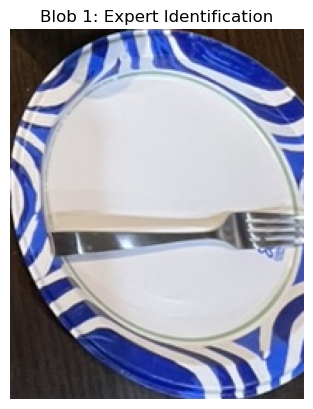

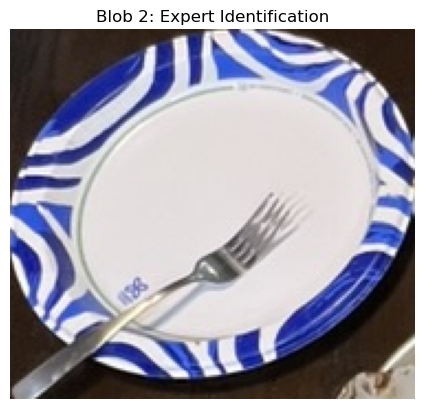

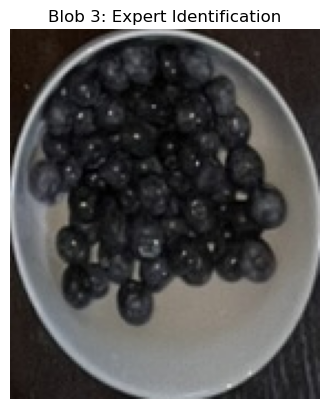

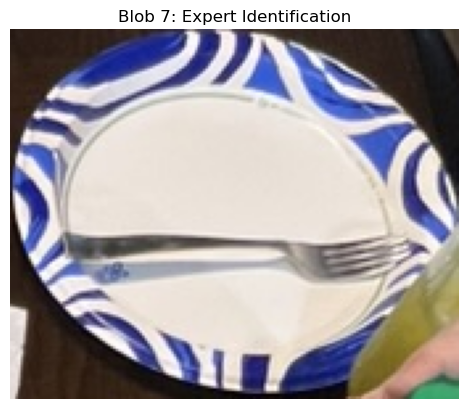

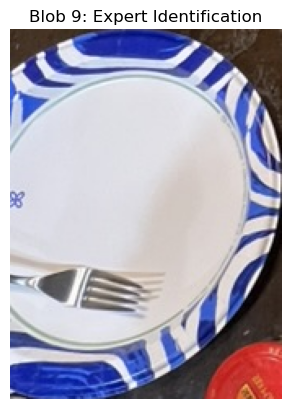

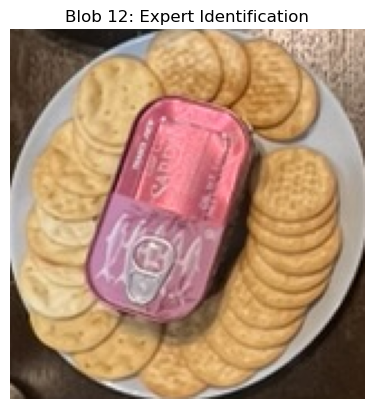

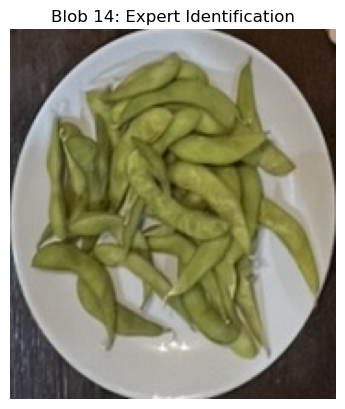

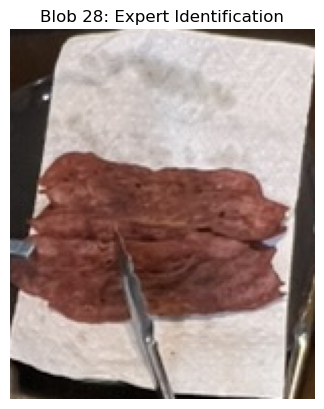

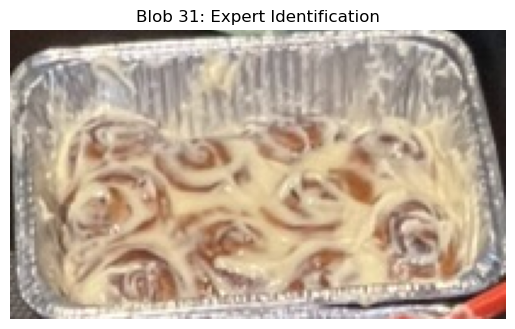

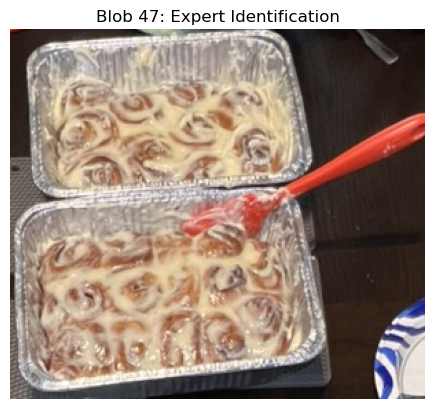

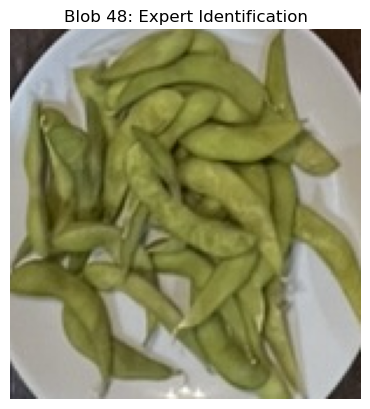

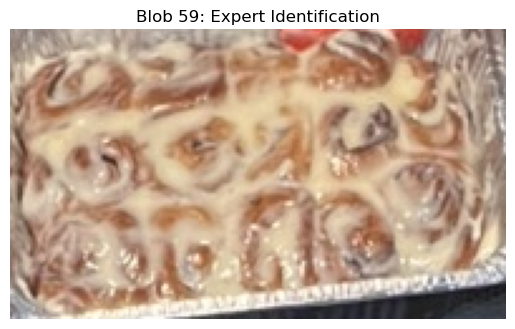

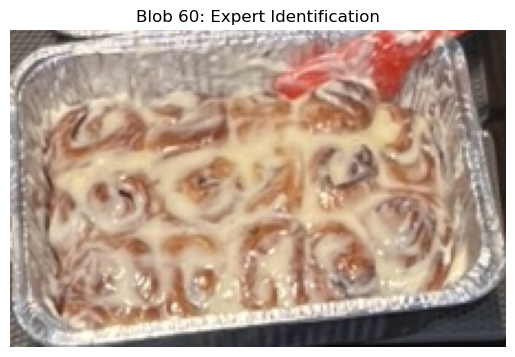

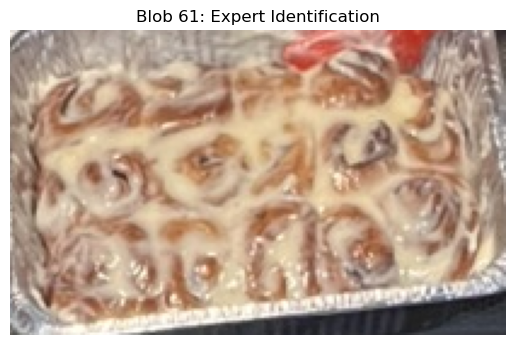

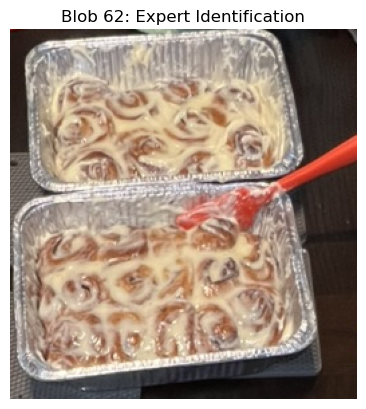

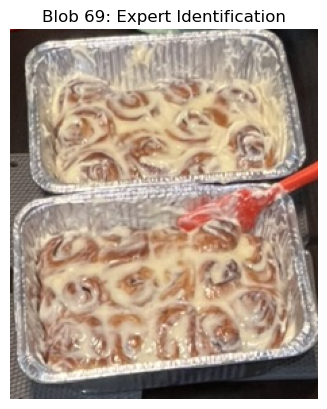

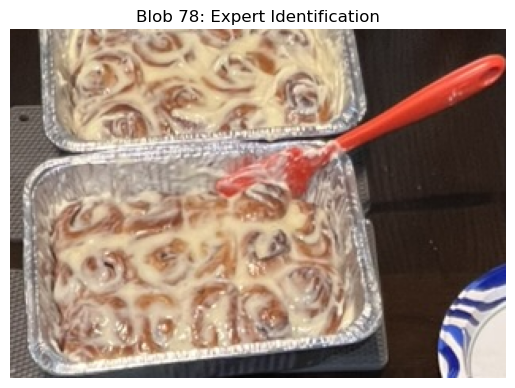

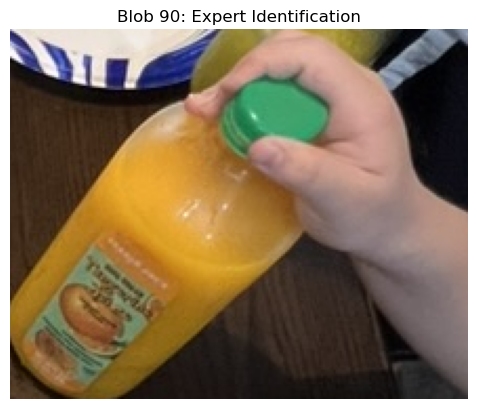

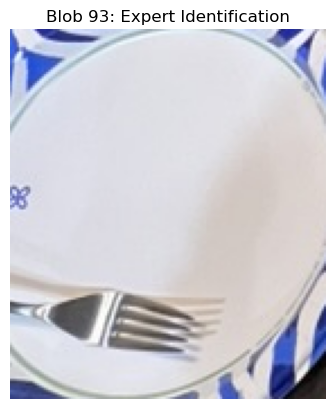

In [51]:
from ultralytics import FastSAM
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the model
model = FastSAM('FastSAM-s.pt') 

# 2. Run the scout
img_path = 'data/test_images/assorted_breakfast.jpeg'
results = model(img_path, device='mps', retina_masks=True, imgsz=1024, conf=0.4, iou=0.9)

# 3. Get the masks directly from the results
# Instead of using FastSAMPrompt, we just look at the raw masks
masks = results[0].masks.data.cpu().numpy()
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Total blobs found: {len(masks)}")

# 4. Crop and Show Each Blob
for i, mask in enumerate(masks):

    # Calculate the total number of pixels in this blob
    blob_size = np.sum(mask > 0)
    
    # Only keep blobs that are at least 5% of the total image size
    # (Adjust 0.05 based on your testing)
    min_pixels = image.shape[0] * image.shape[1] * 0.02 
    
    if blob_size < min_pixels:
        continue  # Skip tiny things like individual peppercorns
    
    # Find where the mask is "active"
    pos = np.where(mask > 0)
    if len(pos[0]) == 0: continue
    
    # Get the bounding box
    ymin, ymax, xmin, xmax = np.min(pos[0]), np.max(pos[0]), np.min(pos[1]), np.max(pos[1])
    crop = image[ymin:ymax, xmin:xmax]
    
    # Visualize the "Expert Input"
    plt.imshow(crop)
    plt.title(f"Blob {i}: Expert Identification")
    plt.axis('off')
    plt.show()

In [40]:
# # 5. Crop and display each "Blob" for the Expert
# for i, box in enumerate(results[0].boxes.xyxy):
#     # Convert coordinates to integers
#     x1, y1, x2, y2 = box.cpu().numpy().astype(int)
    
#     # Crop the original image
#     img = cv2.imread('data/test_images/hot_pot_christmas.jpeg')
#     crop = img[y1:y2, x1:x2]
    
#     # Show what the "Expert" will see
#     plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
#     plt.title(f"Blob {i}: Ready for Identification")
#     plt.axis('off')
#     plt.show()

In [52]:
import torch
from torchvision import models, transforms
from PIL import Image
import cv2
import numpy as np

# 1. Initialize EfficientNet-B0 (the "Expert")
expert_model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# 2. Re-shape the final layer to match your 241 food classes
num_ftrs = expert_model.classifier[1].in_features
expert_model.classifier[1] = torch.nn.Linear(num_ftrs, 241)

# Set to evaluation mode and move to Mac GPU (mps)
expert_model.to('mps').eval()

# 3. Define the Expert's "Eyeglasses" (Preprocessing)
# EfficientNet expects specific sizing and normalization to work accurately.
preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [54]:
# # Assuming 'image' is your original BGR image and 'masks' are from FastSAM
# final_log = []

# for i, mask in enumerate(masks):
#     # Filter by size to keep it sustainable (skip tiny noise)
#     if np.sum(mask) < (image.shape[0] * image.shape[1] * 0.01): 
#         continue

#     # Get coordinates for the crop
#     pos = np.where(mask > 0)
#     ymin, ymax, xmin, xmax = np.min(pos[0]), np.max(pos[0]), np.min(pos[1]), np.max(pos[1])
    
#     # Snip the blob
#     crop_bgr = image[ymin:ymax, xmin:xmax]
#     crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
#     pil_img = Image.fromarray(crop_rgb)
    
#     # Prepare and Predict
#     input_tensor = preprocess(pil_img).unsqueeze(0).to('mps')
    
#     with torch.no_grad():
#         output = expert_model(input_tensor)
#         probabilities = torch.nn.functional.softmax(output[0], dim=0)
#         class_id = torch.argmax(probabilities).item()
#         confidence = probabilities[class_id].item()

#     # Use your label_dict to get the English name
#     food_name = label_dict.get(str(class_id), "Unknown Ingredient")
    
#     final_log.append({
#         "Blob_ID": i,
#         "Name": food_name,
#         "Confidence": f"{confidence:.2%}",
#         "Pixels": np.sum(mask)
#     })

# # View your final meal breakdown
# import pandas as pd
# df_results = pd.DataFrame(final_log)
# print(df_results)

In [55]:
import torch
import clip
from PIL import Image
import cv2

# 1. Load CLIP
device = "mps" if torch.backends.mps.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 2. Dynamically create your "Knowledge Base" from your CSV labels
# This is NOT hardcoding because it pulls from whatever dataset you point it to
all_food_names = list(label_dict.values()) 
text_inputs = clip.tokenize(all_food_names).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

# 3. The Handoff Loop
for i, mask in enumerate(masks):
    # (Your existing cropping logic here to get 'pil_img')
    
    # Prepare the image for CLIP
    image_input = preprocess(pil_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Encode the 'blob' into a fingerprint
        image_features = model.encode_image(image_input)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        
        # Search the Knowledge Base (Cosine Similarity)
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        values, indices = similarity[0].topk(3) # Get top 3 matches
    
    # Display results
    print(f"\n--- Blob {i} Analysis ---")
    for value, index in zip(values, indices):
        print(f"Match: {all_food_names[index]:>20s} | Confidence: {value.item():.2%}")


--- Blob 0 Analysis ---
Match:          Potato silk | Confidence: 15.27%
Match:     Shredded cabbage | Confidence: 5.53%
Match:    Cold Rice Noodles | Confidence: 5.20%

--- Blob 1 Analysis ---
Match:          Potato silk | Confidence: 15.27%
Match:     Shredded cabbage | Confidence: 5.53%
Match:    Cold Rice Noodles | Confidence: 5.20%

--- Blob 2 Analysis ---
Match:          Potato silk | Confidence: 15.27%
Match:     Shredded cabbage | Confidence: 5.53%
Match:    Cold Rice Noodles | Confidence: 5.20%

--- Blob 3 Analysis ---
Match:          Potato silk | Confidence: 15.27%
Match:     Shredded cabbage | Confidence: 5.53%
Match:    Cold Rice Noodles | Confidence: 5.20%

--- Blob 4 Analysis ---
Match:          Potato silk | Confidence: 15.27%
Match:     Shredded cabbage | Confidence: 5.53%
Match:    Cold Rice Noodles | Confidence: 5.20%

--- Blob 5 Analysis ---
Match:          Potato silk | Confidence: 15.27%
Match:     Shredded cabbage | Confidence: 5.53%
Match:    Cold Rice Noodles 